# Numbers for the data description paper

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import re
import glob
from tqdm.notebook import tqdm

from funcs_support import get_filepaths,get_params
dir_list = get_params()

## GWL determination example

In [7]:
gwls = xr.open_dataset(dir_list['aux']+'gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_fromAmon.nc').load()

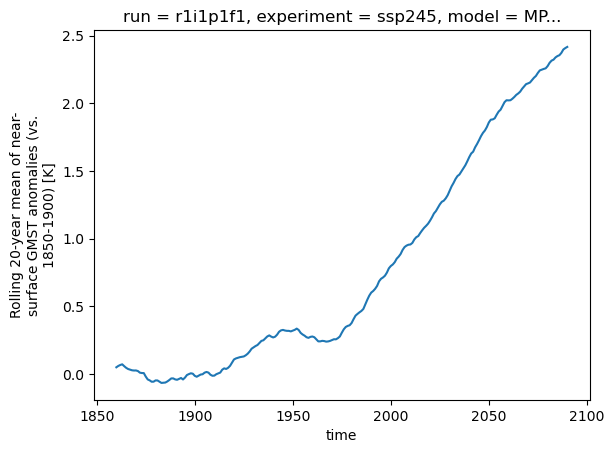

In [18]:
gwls.isel(memberid=5).tasanom.plot()

In [32]:
gwl = 1

gwl_year = gwls['year'][np.where((gwls.isel(memberid=5).tasanom>gwl))[0][0]].values

In [29]:
gwls_tmp = gwls.isel(memberid=5).tasanom.sel(year=slice(gwl_year-2,gwl1_year+2))

In [42]:
start_year = int(gwl_year - 20 / 2)
end_year = int(gwl_year + (20 / 2 - 1))

In [43]:
print(f'{gwls_tmp.model.values} {gwls_tmp.experiment.values} {gwls_tmp.run.values} crosses GWL{str(gwl)} in {str(gwl_year)}')
print(f'{str(gwl_year-1)}: {str(np.round(gwls_tmp.isel(year=1).values,2))}')
print(f'{str(gwl_year)}: {str(np.round(gwls_tmp.isel(year=2).values,2))}')
print(f'Thus, the "GWL{str(gwl)}" data for this model run spans from {str(start_year)} to {str(end_year)}')

MPI-ESM1-2-LR ssp245 r1i1p1f1 crosses GWL1 in 2013
2012: 0.99
2013: 1.01
Thus, the "GWL1" data for this model run spans from 2003 to 2022


In [ ]:
# Now, how long it takes to reach GWL2 under SSP2.45, 5.85
# Note that this is all GWLs calculated, not all of which may be present in the BCD-ME
# if did not have daily data published? 

In [57]:
cross_years = (gwls.tasanom>2).argmax('year')
# Filter out runs that never cross GWL2
cross_years = cross_years.where(cross_years>0) 
# Go from index to year
cross_years = gwls.year.isel(year=cross_years.dropna('memberid').astype(int))
# Get average year index
avg_cross_years = cross_years.groupby('experiment').mean()

In [64]:
print(f'Average year of crossing GWL 2: \n'+
      '\n'.join([exp+': '+str(int(np.round(avg_cross_years.sel(experiment=exp).values))) for exp in ['ssp245','ssp585']]))

Average year of crossing GWL 2: 
ssp245: 2046
ssp585: 2039


## Ensemble size

In [10]:
fns = glob.glob('/glade/campaign/cgd/cas/schwarzwald/bcd_me/*_qdm_*.zarr')
fns = np.sort(fns)

In [45]:
has_data_array = xr.concat([xr.open_zarr(fn).has_data for fn in fns],
          dim='idv',join='outer').load()
has_data_array = has_data_array.where(~np.isnan(has_data_array),0)

In [46]:
total_nruns = has_data_array.any('gwl').sum('idv')

In [47]:
print(f'Number of total runs (`tas`): {str(total_nruns.sel(variable='tas').values)}')
print(f'Number of total runs (`tasmax`): {str(total_nruns.sel(variable='tasmax').values)}')
print(f'Number of models: {str(len(fns))}')

Number of total runs (`tas`): 365
Number of total runs (`tasmax`): 190
Number of models: 12


### Ensemble tables

In [28]:
def ssp_parser(name):
    ''' Convert from lowercase filename SSPs to "official" SSP names '''
    m = re.match(r'ssp(\d)(\d)(\d)(-over)?', name.lower())
    if not m:
        raise ValueError(f'Unrecognized SSP format: {name}')

    major, tens, ones, over = m.groups()
    forcing = f'{tens}.{ones}'
    suffix = '-OS' if over else ''

    return f'SSP{major}-{forcing}{suffix}'

In [30]:
df = get_filepaths(source_dir = 'proc')
#-------- Number of runs per exp per model table
df_tas = (df.query('varname == "tas" and proj_method == "QDM" and proj_base == "ERA5-025"').
         groupby(['model','exp']).count()[['varname']].
         reset_index().
         pivot(columns='exp',index='model'))
df_tas.columns = df_tas.columns.droplevel()

# Rename SSPs to "offical" names
df_tas.columns = [ssp_parser(c) for c in df_tas.columns]

# Create total number of runs per model column
df_tas['Total'] = df_tas.sum(axis=1)

# Make numbers into strings, with '-' for no runs
df_tas = df_tas.astype(str).replace('nan','-',regex=True).replace(r'\.0','',regex=True)

# Capitalize
df_tas.index = df_tas.index.rename('Model')

# Print latex table
#print(df_tas.to_latex(formatters={"name": str.upper},float_format="{:.1f}".format))

In [98]:
#-------- Number of runs per exp per model table
df_tas = has_data_array.any('gwl').groupby(['model','experiment']).sum().to_dataframe().reset_index().pivot(columns='experiment',index = ['variable','model'])
df_tas.columns = df_tas.columns.droplevel()

# Rename SSPs to "offical" names
df_tas.columns = [ssp_parser(c) for c in df_tas.columns]

# Create total number of runs per model column
df_tas['Total'] = df_tas.sum(axis=1)

# Make numbers into strings, with '-' for no runs
df_tas = df_tas.astype(str).replace('nan','-',regex=True).replace(r'\.0','',regex=True)

# Capitalize
df_tas.index = df_tas.index.rename({'model':'Model','variable':'Variable'})

# Print latex table
print(df_tas.to_latex(formatters={"name": str.upper},float_format="{:.1f}".format))

\begin{tabular}{lllllllllll}
\toprule
 &  & SSP1-1.9 & SSP1-2.6 & SSP2-4.5 & SSP3-7.0 & SSP4-3.4 & SSP4-6.0 & SSP5-3.4-OS & SSP5-8.5 & Total \\
Variable & Model &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{12}{*}{tas} & ACCESS-ESM1-5 & - & - & 19 & - & - & - & - & 5 & 24 \\
 & CESM2-WACCM & - & - & 3 & 2 & - & - & - & 3 & 8 \\
 & CNRM-CM6-1 & - & - & 6 & 6 & - & - & - & 6 & 18 \\
 & CNRM-ESM2-1 & 5 & 5 & 10 & 5 & 3 & 3 & 5 & 5 & 41 \\
 & CanESM5 & - & - & 41 & 15 & - & - & - & 30 & 86 \\
 & EC-Earth3 & - & - & 21 & 7 & - & - & - & 7 & 35 \\
 & EC-Earth3-Veg & - & - & 5 & 4 & - & - & - & 4 & 13 \\
 & FGOALS-g3 & - & - & 3 & 4 & - & - & - & 3 & 10 \\
 & IPSL-CM6A-LR & - & - & 11 & 11 & - & - & - & 6 & 28 \\
 & MIROC6 & - & - & 29 & 3 & - & - & - & 28 & 60 \\
 & MPI-ESM1-2-LR & - & - & 10 & 10 & - & - & - & 10 & 30 \\
 & MRI-ESM2-0 & - & - & 5 & 5 & - & - & - & 2 & 12 \\
\cline{1-11}
\multirow[t]{12}{*}{tasmax} & ACCESS-ESM1-5 & - & - & 0 & - & - & - & - & 6 & 6 \\
 & CESM2-WACCM &

In [68]:
#-------- Citations / number of runs per exp per model table

df_all = (df.query('(varname == "tas" or varname == "tasmax") and proj_method == "QDM" and proj_base == "ERA5-025"').
         groupby(['model','exp','varname']).count()[['freq']].
 reset_index().rename({'model':'Model','exp':'Experiment'},axis=1).
 pivot(columns = ['varname'],index=['Model','Experiment']))
df_all.columns = df_all.columns.droplevel()

# This will be used to create natbib file
cite_strs = dict()

# Add \citet{} strings to table
for row in df_all.iterrows():
    if row[0][0] not in cite_strs:
        cite_strs[row[0][0]] = dict()

    cite_code = '_'.join(row[0])
    df_all.loc[row[0],'cite'] = r'\citet{'+cite_code+r'}'
    cite_strs[row[0][0]][row[0][1]] = cite_code

# Make number of runs integer strings with '-' instead of nans
for var in ['tas','tasmax']:
    df_all[var] = df_all[var].astype(str)
    df_all.loc[:,var] = df_all.loc[:,var].astype(str).replace('nan','-',regex=True).replace(r'\.0','',regex=True)
# Rename columns
df_all.columns = ['tas','tasmax','Citation']
# Rename experiments to "official" SSP names#
df_all.index = df_all.index.set_levels([ssp_parser(k) for k in df_all.index.levels[1]],level = 1)

# Print latex table
#print(df_all.to_latex(longtable=True))

In [97]:
df_long = has_data_array.any('gwl').groupby(['model','experiment']).sum().sum('variable').stack(allv = ['model','experiment'])
df_long = df_long.where(df_long>0,drop=True)
df_long = df_long.to_dataframe()
#df_long.columns = df_long.columns.droplevel()

# This will be used to create natbib file
cite_strs = dict()

# Add \citet{} strings to table
for row in df_long.iterrows():
    if row[0][0] not in cite_strs:
        cite_strs[row[0][0]] = dict()

    cite_code = '_'.join(row[0])
    df_long.loc[row[0],'cite'] = r'\citet{'+cite_code+r'}'
    cite_strs[row[0][0]][row[0][1]] = cite_code


# Rename columns
df_long = df_long.drop('has_data',axis=1)
df_long.columns = ['Citation']

# Capitalize
df_long.index = df_long.index.rename({'model':'Model','experiment':'Experiment'})

# Rename experiments to "official" SSP names
df_long.index = df_long.index.set_levels([ssp_parser(k) for k in df_long.index.levels[1]],level = 1)

# Print latex table
#print(df_long.to_latex(longtable=True))

In [94]:
#-------- Generate natbib file for CMIP6 citations
# Load CMIP6 data references from https://www.wdc-climate.de/ords/f?p=127:2
cits = pd.read_csv(dir_list['aux']+'CMIP6 Data References.csv',encoding = "ISO-8859-1")

output_fn = dir_list['aux']+'modlist.bib'

# Remove file if necessary
if os.path.exists(output_fn):
    os.remove(output_fn)
    
# Open plaintext file
file1 = open(output_fn, 'w') 

# Process by file 
for row in cits.iterrows():
    # Get full reference
    ref = row[1]['Data Reference']

    # Get mod, exp
    mod = row[1]['SOURCE_ID']
    exp = row[1]['EXPERIMENT_ID']

    # Process if mod used in paper
    if mod not in cite_strs:
        continue
    
    # Process if exp used in paper
    if exp not in cite_strs[mod]:
        continue
    
    # Get locations of certain fields in ref
    year_match = re.search(r'\([0-9]{4}\)\.',ref)
    pub_match = re.search('Earth System Grid Federation',ref)
    doi_match = re.search(r'doi\:.*\s',ref)
    doi = doi_match[0][20:].strip()
    
    # Get author
    auth = re.sub(r'\;',' and',ref[0:year_match.start()-1])
    # If only one institutional author (no ands, commas),
    # wrap in { } for bibtex robustness
    if (',' not in auth) and ('and' not in auth):
        auth = '{'+auth+'}'

    # Get title
    title = re.split(r'\. ',ref)[1]
    # Changing _ to \_ to escape for latex / bibtex
    title = re.sub(r'\_',r'\_',title)
    # Wrappig in { } for bibtex robustness (around capitalization, here)
    title = '{'+title+'}'
    
    
    # Put together bibtex fields
    fields = {'url':'https://doi.org/'+doi,
              'title':title,
              'publisher':re.split(r'\. ',ref)[2],
              'year': year_match[0][1:5],
              'author':auth,
              'doi': doi}

    
    # Get tag
    if type(row[1]['EXPERIMENT_ID']) == str:
        tag = '_'.join([row[1][k] for k in ['SOURCE_ID','EXPERIMENT_ID']])
    else:
        tag = '_'.join([row[1][k] for k in ['SOURCE_ID','ACTIVITY_ID']])

    # Get full bibtex output
    bibtex_output = '@misc{'+tag+',\n'+''.join(['\t'+typ+' = {'+field+'},\n' for typ,field in fields.items()])+'}'

    # Write output
    file1.write(bibtex_output)

    # Add empty line
    file1.write('\n\n')

# Close file, finish saving
file1.close()

In [140]:
df_bygwl = has_data_array.sel(gwl=slice(1,None)).set_index(idv = ['model','run','experiment']).unstack().sum(('run','experiment')).rename({'gwl':'GWL reached:'}).to_dataframe().reset_index().pivot(columns = 'GWL reached:',
                                                                                                                      index = ['variable','model'])
df_bygwl.columns = df_bygwl.columns.droplevel()

# Get total number of runs by GWL
totals = df_bygwl.groupby(['variable']).sum().astype(int)
totals['model'] = 'Total'
totals = totals.reset_index().set_index(['variable','model'])
# Concat back in
df_bygwl = pd.concat([df_bygwl,totals]).sort_index()

# Capitalize
df_bygwl.index = df_bygwl.index.rename({'model':'Model','variable':'Variable'})

# Change to integer dtype
df_bygwl = df_bygwl.astype(int)

# Print latex table
print(df_bygwl.to_latex())



\begin{tabular}{llrrrrrrr}
\toprule
 & GWL reached: & 1.000000 & 1.500000 & 2.000000 & 2.500000 & 3.000000 & 3.500000 & 4.000000 \\
Variable & Model &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{13}{*}{tas} & ACCESS-ESM1-5 & 24 & 24 & 24 & 24 & 5 & 5 & 5 \\
 & CESM2-WACCM & 8 & 8 & 8 & 7 & 7 & 4 & 3 \\
 & CNRM-CM6-1 & 18 & 18 & 18 & 18 & 15 & 12 & 6 \\
 & CNRM-ESM2-1 & 41 & 41 & 31 & 26 & 13 & 7 & 5 \\
 & CanESM5 & 86 & 86 & 86 & 86 & 86 & 86 & 79 \\
 & EC-Earth3 & 35 & 35 & 35 & 35 & 32 & 15 & 10 \\
 & EC-Earth3-Veg & 13 & 13 & 13 & 13 & 13 & 9 & 6 \\
 & FGOALS-g3 & 10 & 10 & 10 & 7 & 3 & 0 & 0 \\
 & IPSL-CM6A-LR & 28 & 28 & 28 & 28 & 28 & 18 & 17 \\
 & MIROC6 & 60 & 34 & 34 & 31 & 28 & 0 & 0 \\
 & MPI-ESM1-2-LR & 30 & 30 & 30 & 20 & 16 & 6 & 0 \\
 & MRI-ESM2-0 & 12 & 8 & 8 & 8 & 7 & 2 & 0 \\
 & Total & 365 & 335 & 325 & 303 & 253 & 164 & 131 \\
\cline{1-9}
\multirow[t]{13}{*}{tasmax} & ACCESS-ESM1-5 & 6 & 6 & 6 & 6 & 6 & 6 & 6 \\
 & CESM2-WACCM & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 & CNRM-

,gwl,0.61,1.0,1.5,2.0,2.5,3.0,3.5,4.0
variable,model,,,,,,,,
tas,Total,365,365,335,325,303,253,164,131
tasmax,Total,190,190,178,176,156,137,76,51


In [ ]:
#-------- Table of number of runs per model that reach a GWL

def df_to_nruns_by_gwl_table(df):
    ''' df of get_filepaths() files, counted by number of runs 
    per model that reach a certain GWL '''
    df = df.set_index(['model','exp','run','proj_base'])
    df = df.sort_index()

    # Get max GWL reached by file
    df.loc[:,'Max GWL'] = np.nan
    for idx in tqdm(df.index):
        ds_tmp = xr.open_zarr(df.loc[idx,'path'])
        df.loc[idx,'Max GWL'] = ds_tmp.gwl.max().values

    # Count number of runs / model that reach GWL X, and 
    # pivot to have GWL as a column
    df = (df[['Max GWL']].
            reset_index().
            groupby(['model','Max GWL']).count()[['exp']].
            reset_index().
            pivot(columns = 'Max GWL',index='model'))

    # Replace NaNs (GWLs that aren't the max of any file) with 0s
    df = df.where(~np.isnan(df),0)
    # Get number of runs that reach at least GWL X
    df = df.iloc[:,::-1].cumsum(axis=1).iloc[:,::-1]

    # Get total number of runs across models by GWL 
    df.loc['Total',:] = df.sum()

    # Housekeeping
    df = df.astype(int)
    df.columns = df.columns.droplevel()

    return df

# Generate for tas
df_tas_bygwl = (df.query('varname == "tas" and proj_method == "QDM" and proj_base == "ERA5-025"'))
df_tas_bygwl = df_to_nruns_by_gwl_table(df_tas_bygwl)

# Generate for tasmax
df_tasmax_bygwl = (df.query('varname == "tasmax" and proj_method == "QDM" and proj_base == "ERA5-025"'))
df_tasmax_bygwl = df_to_nruns_by_gwl_table(df_tasmax_bygwl)

# Define variables
df_tasmax_bygwl.loc[:,'Variable'] = 'tasmax'
df_tas_bygwl.loc[:,'Variable'] = 'tas'

# Combine into single latex table
#print(pd.concat([df_tas_bygwl,
#           df_tasmax_bygwl]).reset_index().set_index(['Variable','model']).to_latex())

### Grid sizes of CMIP models

In [7]:
df = get_filepaths().query('varname == "tas"')
df = df.reset_index().drop('index',axis=1)
df = df.loc[[row[0] for row in df.iterrows() if re.search('r[0-9].*i[0-9].*',str(row[1]['run']))]]

In [19]:
grid_bounds = {}
for row in df.iterrows():
    if row[1]['model'] not in grid_bounds:
        try:
            ds_tmp = xr.open_dataset(row[1]['path'])
        except:
            try:
                ds_tmp = xr.open_dataset(row[1]['path'],decode_times = False)
            except:
                continue
        grid_bounds[row[1]['model']] = tuple([float(ds_tmp[v].diff(v).mean(v).round(3).values)
                                        for v in ['lat','lon']])
grid_bounds = {str(mod):grid_bounds[mod] for mod in np.sort([k for k in grid_bounds])}

In [20]:
grid_bounds

{'ACCESS-ESM1-5': (1.25, 1.875),
 'CESM2-WACCM': (0.942, 1.25),
 'CNRM-CM6-1': (1.401, 1.406),
 'CNRM-ESM2-1': (1.401, 1.406),
 'CanESM5': (2.79, 2.812),
 'EC-Earth3': (0.702, 0.703),
 'EC-Earth3-Veg': (0.702, 0.703),
 'FGOALS-g3': (2.129, 2.0),
 'GISS-E2-1-G': (2.0, 2.5),
 'IPSL-CM6A-LR': (1.268, 2.5),
 'MIROC6': (1.401, 1.406),
 'MPI-ESM1-2-LR': (1.865, 1.875),
 'MRI-ESM2-0': (1.121, 1.125)}

## Size of final dataset

In [3]:
fns = glob.glob('/glade/campaign/cgd/cas/schwarzwald/bcd_me/*.zarr')
fns = np.sort(fns)

In [4]:
sizes = {re.split(r'\/',fn)[-1]:xr.open_zarr(fn,decode_timedelta=False).nbytes / (1000**4)
         for fn in fns}

In [9]:
print(f'Total uncompressed size of dataset: {str(np.round(np.sum([siz for f,siz in sizes.items()]),2))} TB')

Total uncompressed size of dataset: 97.33 TB
